In [ ]:
import os
import sys
import time
import h5py
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Paths
THIS_DIR = os.getcwd()
MODULE_DIR = THIS_DIR
REPO_DIR = os.path.abspath(os.path.join(MODULE_DIR, '..'))

sys.path.insert(0, MODULE_DIR)

import tool  # noqa: E402
import importlib
from model import ParticleTransformerKD  # noqa: E402
importlib.reload(tool)  # noqa: E402

# Reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Experiment output
RUN_NAME = 'T_H_H+KD'
OUT_DIR = os.path.join(MODULE_DIR, 'runs', RUN_NAME)
FIG_DIR = os.path.join(OUT_DIR, 'figs')
CKPT_DIR = os.path.join(OUT_DIR, 'ckpts')

tool.ensure_dir(FIG_DIR)
tool.ensure_dir(CKPT_DIR)

CONFIG = {
    'data_path': os.path.join(REPO_DIR, 'test.h5'),
    'n_jets': 100000,
    'max_particles': 100,
    'hlt_effects': {
        'pt_resolution': 0.10,
        'eta_resolution': 0.03,
        'phi_resolution': 0.03,
        'pt_threshold_offline': 0.5,
        'pt_threshold_hlt': 1.5,
        'merge_enabled': True,
        'merge_radius': 0.01,
        'efficiency_loss': 0.03,
    },
    'tagger': {
        'input_dim': 7,
        'embed_dim': 128,
        'num_heads': 8,
        'num_layers': 4,
        'ff_dim': 512,
        'dropout': 0.1,
    },
    'training': {
        'batch_size': 512,
        'epochs': 50,
        'lr': 5e-4,
        'weight_decay': 1e-5,
        'warmup_epochs': 3,
        'patience': 5,
    },
    'kd': {
        'temperature': 3.0,
        'alpha_kd': 0.5,
        'alpha_attn': 0.2,
    },
    'io': {
        'run_name': RUN_NAME,
        'out_dir': OUT_DIR,
        'fig_dir': FIG_DIR,
        'ckpt_dir': CKPT_DIR,
        'config_path': os.path.join(OUT_DIR, 'config.json'),
        # If any of these are set to an existing file path, training will be skipped and weights reloaded.
        'load_teacher': None,
        'load_baseline': None,
        'load_student': None,
    },
}

tool.save_config(CONFIG, CONFIG['io']['config_path'])
print('Data path:', CONFIG['data_path'])
print('Run dir:', CONFIG['io']['out_dir'])

Device: cuda
Data path: d:\PracticeTagging\test.h5
Run dir: d:\PracticeTagging\unmerge\runs\T_H_H+KD


In [2]:
# Load data
n = int(CONFIG['n_jets'])
S = int(CONFIG['max_particles'])

with h5py.File(CONFIG['data_path'], 'r') as f:
    labels = f['labels'][:n].astype(np.int64)
    weights = f['weights'][:n].astype(np.float32)
    pt = f['fjet_clus_pt'][:n, :S].astype(np.float32)
    eta = f['fjet_clus_eta'][:n, :S].astype(np.float32)
    phi = f['fjet_clus_phi'][:n, :S].astype(np.float32)
    E = f['fjet_clus_E'][:n, :S].astype(np.float32)

constituents_raw = np.stack([pt, eta, phi, E], axis=-1)  # [N,S,4]
masks_raw = pt > 0

print('Raw:', constituents_raw.shape, 'mask:', masks_raw.shape)
print('Signal:', int(labels.sum()), 'Bkg:', int((1 - labels).sum()))


Raw: (50000, 100, 4) mask: (50000, 100)
Signal: 25057 Bkg: 24943


In [ ]:
# HLT simulation + offline threshold + features
constituents_hlt, masks_hlt = tool.apply_hlt_effects(constituents_raw, masks_raw, CONFIG, seed=seed)

pt_thr_off = float(CONFIG['hlt_effects']['pt_threshold_offline'])
masks_off = masks_raw & (constituents_raw[:, :, 0] >= pt_thr_off)
constituents_off = constituents_raw.copy()
constituents_off[~masks_off] = 0

features_off = tool.compute_features(constituents_off, masks_off)
features_hlt = tool.compute_features(constituents_hlt, masks_hlt)
print('Features:', features_off.shape, features_hlt.shape)

# split
idx = np.arange(len(labels))
train_idx, temp_idx = train_test_split(idx, test_size=0.3, random_state=seed, stratify=labels)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=seed, stratify=labels[temp_idx])
print(f"Split: train={len(train_idx):,} val={len(val_idx):,} test={len(test_idx):,}")


Features: (50000, 100, 7) (50000, 100, 7)
Split: train=35,000 val=7,500 test=7,500
Standardization done.


In [17]:
# standardize using OFFLINE TRAIN stats
# feat_means_off, feat_stds_off = tool.get_stats(features_off, masks_off, train_idx)
# feat_means_hlt, feat_stds_hlt = tool.get_stats(features_hlt, masks_hlt, train_idx)
feat_means_off, feat_stds_off = tool.get_stats(features_off, masks_off, train_idx)
features_off_std = tool.standardize(features_off, masks_off, feat_means_off, feat_stds_off, clip=10.0)
features_hlt_std = tool.standardize(features_hlt, masks_hlt, feat_means_off, feat_stds_off, clip=10.0)
print('Standardization done.')

Standardization done.


Plotting feature distributions on TRAIN split (sampled)...
[OFF] dEta: mean=0.0001623 std=1.003 p50=0.00286
[HLT] dEta: mean=-0.002798 std=1.156 p50=0.0004772
[OFF] dPhi: mean=0.005204 std=0.9994 p50=0.002031
[HLT] dPhi: mean=0.003014 std=1.148 p50=2.36e-05
[OFF] log_pt: mean=0.002487 std=0.9989 p50=-0.1266
[HLT] log_pt: mean=0.1587 std=1.149 p50=0.1296
[OFF] log_E: mean=0.001966 std=0.9987 p50=-0.1272
[HLT] log_E: mean=0.1665 std=1.146 p50=0.136
[OFF] log_pt/jet_pt: mean=0.001492 std=0.9996 p50=-0.1283
[HLT] log_pt/jet_pt: mean=0.2352 std=1.122 p50=0.2035
[OFF] log_E/jet_E: mean=0.001475 std=0.9998 p50=-0.127
[HLT] log_E/jet_E: mean=0.234 std=1.122 p50=0.2034
[OFF] dR: mean=-0.0008812 std=1.003 p50=-0.3508
[HLT] dR: mean=0.2272 std=1.079 p50=-0.1102
Saved figure: d:\PracticeTagging\unmerge\runs\T_H_H+KD\figs\feat_dists_train.png


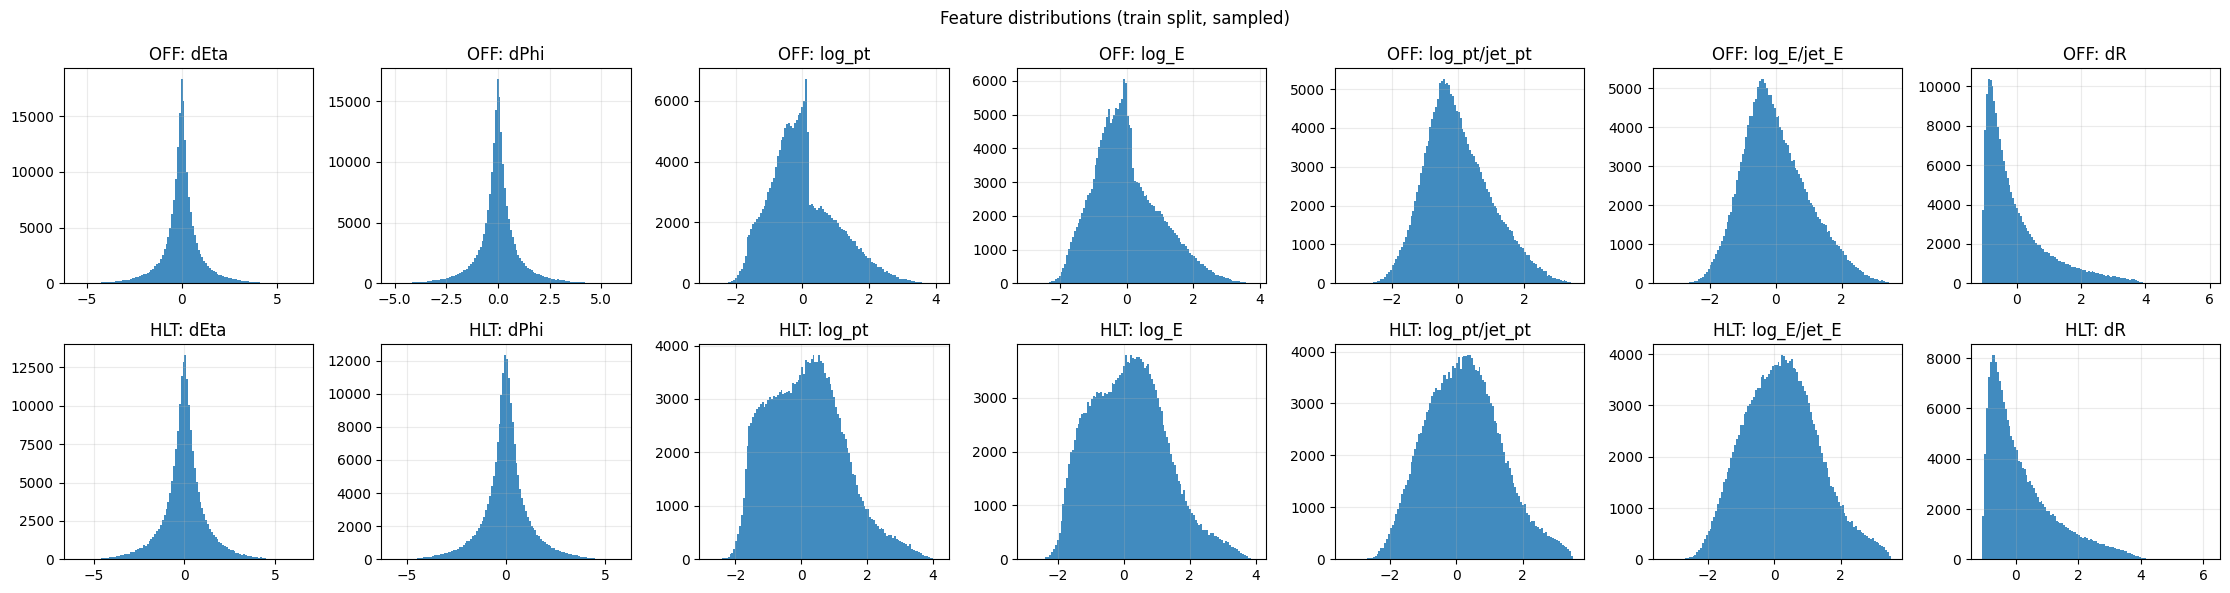

In [18]:
# Feature distribution visualization (moved into `tool.py`)

# By default we inspect standardized features used by the model.
feat_off_to_plot = features_off_std
feat_hlt_to_plot = features_hlt_std

# If you want raw engineered features instead, uncomment:
# feat_off_to_plot = features_off
# feat_hlt_to_plot = features_hlt

feat_fig_path = os.path.join(CONFIG['io']['fig_dir'], 'feat_dists_train.png')

print('Plotting feature distributions on TRAIN split (sampled)...')
tool.plot_feat_dists(
    feat_off_to_plot,
    masks_off,
    feat_hlt_to_plot,
    masks_hlt,
    jet_idx=train_idx,
    title='Feature distributions (train split, sampled)',
    bins=120,
    max_vals=200_000,
    clip=(-10, 10),
    seed=seed,
    save_path=feat_fig_path,
    dpi=160,
)


In [19]:
# DataLoaders
BS = int(CONFIG['training']['batch_size'])

train_ds = tool.JetDataset(features_off_std[train_idx], features_hlt_std[train_idx], labels[train_idx], masks_off[train_idx], masks_hlt[train_idx], weights[train_idx])
val_ds = tool.JetDataset(features_off_std[val_idx], features_hlt_std[val_idx], labels[val_idx], masks_off[val_idx], masks_hlt[val_idx], weights[val_idx])
test_ds = tool.JetDataset(features_off_std[test_idx], features_hlt_std[test_idx], labels[test_idx], masks_off[test_idx], masks_hlt[test_idx], weights[test_idx])

train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BS)
test_loader = DataLoader(test_ds, batch_size=BS)

print('Loaders ready, BS=', BS)


Loaders ready, BS= 512


In [20]:
# Train Teacher (offline), Baseline (HLT), Student+KD

io = CONFIG['io']
teacher_ckpt = os.path.join(io['ckpt_dir'], 'teacher.pt')
baseline_ckpt = os.path.join(io['ckpt_dir'], 'baseline.pt')
student_ckpt = os.path.join(io['ckpt_dir'], 'student_kd.pt')

# Persist produced artifact paths into config
io['teacher_ckpt'] = teacher_ckpt
io['baseline_ckpt'] = baseline_ckpt
io['student_ckpt'] = student_ckpt
tool.save_config(CONFIG, io['config_path'])

epochs = int(CONFIG['training']['epochs'])
lr = float(CONFIG['training']['lr'])
wd = float(CONFIG['training']['weight_decay'])
warm = int(CONFIG['training']['warmup_epochs'])
pat = int(CONFIG['training']['patience'])

# 1) Teacher
teacher = ParticleTransformerKD(**CONFIG['tagger']).to(device)
load_teacher = io.get('load_teacher')
if load_teacher:
    print(f"Loading teacher checkpoint: {load_teacher}")
    tool.load_checkpoint(teacher, load_teacher, map_location=device)
    best_auc_t = None
else:
    opt_t = torch.optim.AdamW(teacher.parameters(), lr=lr, weight_decay=wd)
    sch_t = tool.get_scheduler(opt_t, warm, epochs)
    best_auc_t, best_state_t, no_imp = 0.0, None, 0
    for ep in range(1, epochs + 1):
        loss, _ = tool.train_standard(teacher, train_loader, opt_t, device, 'off', 'mask_off')
        val_auc, _, _ = tool.evaluate(teacher, val_loader, device, 'off', 'mask_off')
        sch_t.step()
        if val_auc > best_auc_t + 1e-4:
            best_auc_t = val_auc
            best_state_t = {k: v.detach().cpu().clone() for k, v in teacher.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if ep == 1 or ep % 5 == 0:
            print(f"[Teacher] ep={ep:03d} val_auc={val_auc:.4f} best={best_auc_t:.4f} no_imp={no_imp}")
        if no_imp >= pat:
            print('[Teacher] Early stopping')
            break
    if best_state_t is not None:
        teacher.load_state_dict(best_state_t)
    tool.save_checkpoint(teacher, teacher_ckpt, extra={'best_val_auc': best_auc_t})
    print(f"Saved teacher checkpoint: {teacher_ckpt}")

auc_t, p_t, y_t = tool.evaluate(teacher, test_loader, device, 'off', 'mask_off')
print(f"Teacher test AUC={auc_t:.4f}")

# 2) Baseline HLT
baseline = ParticleTransformerKD(**CONFIG['tagger']).to(device)
load_baseline = io.get('load_baseline')
if load_baseline:
    print(f"Loading baseline checkpoint: {load_baseline}")
    tool.load_checkpoint(baseline, load_baseline, map_location=device)
    best_auc_b = None
else:
    opt_b = torch.optim.AdamW(baseline.parameters(), lr=lr, weight_decay=wd)
    sch_b = tool.get_scheduler(opt_b, warm, epochs)
    best_auc_b, best_state_b, no_imp = 0.0, None, 0
    for ep in range(1, epochs + 1):
        loss, _ = tool.train_standard(baseline, train_loader, opt_b, device, 'hlt', 'mask_hlt')
        val_auc, _, _ = tool.evaluate(baseline, val_loader, device, 'hlt', 'mask_hlt')
        sch_b.step()
        if val_auc > best_auc_b + 1e-4:
            best_auc_b = val_auc
            best_state_b = {k: v.detach().cpu().clone() for k, v in baseline.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if ep == 1 or ep % 5 == 0:
            print(f"[HLT] ep={ep:03d} val_auc={val_auc:.4f} best={best_auc_b:.4f} no_imp={no_imp}")
        if no_imp >= pat:
            print('[HLT] Early stopping')
            break
    if best_state_b is not None:
        baseline.load_state_dict(best_state_b)
    tool.save_checkpoint(baseline, baseline_ckpt, extra={'best_val_auc': best_auc_b})
    print(f"Saved baseline checkpoint: {baseline_ckpt}")

auc_b, p_b, y_b = tool.evaluate(baseline, test_loader, device, 'hlt', 'mask_hlt')
print(f"HLT baseline test AUC={auc_b:.4f}")

# 3) Student KD
kd_cfg = {'kd': CONFIG['kd']}
student = ParticleTransformerKD(**CONFIG['tagger']).to(device)
load_student = io.get('load_student')
if load_student:
    print(f"Loading student checkpoint: {load_student}")
    tool.load_checkpoint(student, load_student, map_location=device)
    best_auc_s = None
else:
    opt_s = torch.optim.AdamW(student.parameters(), lr=lr, weight_decay=wd)
    sch_s = tool.get_scheduler(opt_s, warm, epochs)
    best_auc_s, best_state_s, no_imp = 0.0, None, 0
    for ep in range(1, epochs + 1):
        loss, _ = tool.train_kd(student, teacher, train_loader, opt_s, device, kd_cfg)
        val_auc, _, _ = tool.evaluate(student, val_loader, device, 'hlt', 'mask_hlt')
        sch_s.step()
        if val_auc > best_auc_s + 1e-4:
            best_auc_s = val_auc
            best_state_s = {k: v.detach().cpu().clone() for k, v in student.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if ep == 1 or ep % 5 == 0:
            print(f"[KD] ep={ep:03d} val_auc={val_auc:.4f} best={best_auc_s:.4f} no_imp={no_imp}")
        if no_imp >= pat:
            print('[KD] Early stopping')
            break
    if best_state_s is not None:
        student.load_state_dict(best_state_s)
    tool.save_checkpoint(student, student_ckpt, extra={'best_val_auc': best_auc_s})
    print(f"Saved student checkpoint: {student_ckpt}")

auc_kd, p_kd, y_kd = tool.evaluate(student, test_loader, device, 'hlt', 'mask_hlt')
print(f"Student KD test AUC={auc_kd:.4f}")


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[Teacher] ep=001 val_auc=0.8165 best=0.8165 no_imp=0
[Teacher] ep=005 val_auc=0.9011 best=0.9011 no_imp=0
[Teacher] ep=010 val_auc=0.9159 best=0.9276 no_imp=2
[Teacher] ep=015 val_auc=0.9311 best=0.9311 no_imp=4
[Teacher] Early stopping
Saved teacher checkpoint: d:\PracticeTagging\unmerge\runs\T_H_H+KD\ckpts\teacher.pt
Teacher test AUC=0.9316


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[HLT] ep=001 val_auc=0.8154 best=0.8154 no_imp=0
[HLT] ep=005 val_auc=0.8652 best=0.8652 no_imp=0
[HLT] ep=010 val_auc=0.8948 best=0.8948 no_imp=0
[HLT] ep=015 val_auc=0.8979 best=0.8979 no_imp=0
[HLT] ep=020 val_auc=0.8946 best=0.9013 no_imp=1
[HLT] ep=025 val_auc=0.9075 best=0.9075 no_imp=0
[HLT] ep=030 val_auc=0.8994 best=0.9075 no_imp=5
[HLT] Early stopping
Saved baseline checkpoint: d:\PracticeTagging\unmerge\runs\T_H_H+KD\ckpts\baseline.pt
HLT baseline test AUC=0.9033


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[KD] ep=001 val_auc=0.8251 best=0.8251 no_imp=0
[KD] ep=005 val_auc=0.8850 best=0.8850 no_imp=0
[KD] ep=010 val_auc=0.9007 best=0.9010 no_imp=2
[KD] ep=015 val_auc=0.9041 best=0.9058 no_imp=2
[KD] ep=020 val_auc=0.9047 best=0.9078 no_imp=3
[KD] ep=025 val_auc=0.9030 best=0.9132 no_imp=4
[KD] Early stopping
Saved student checkpoint: d:\PracticeTagging\unmerge\runs\T_H_H+KD\ckpts\student_kd.pt
Student KD test AUC=0.9100


Saved figure: d:\PracticeTagging\unmerge\runs\T_H_H+KD\figs\roc_test.png


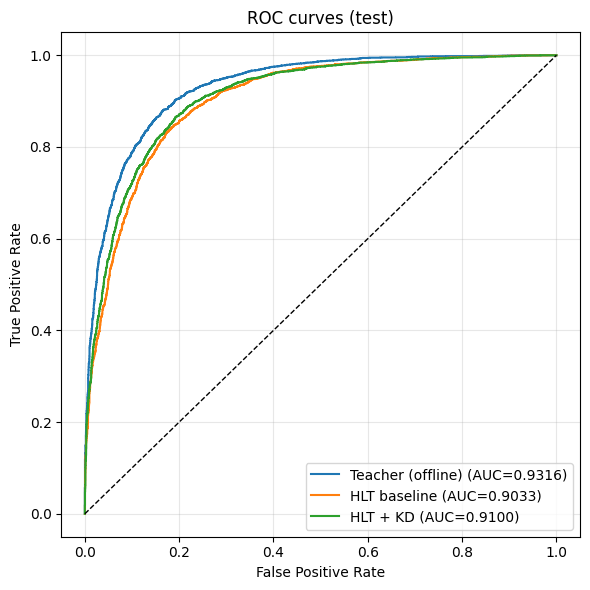

In [21]:
# ROC curves
curves = {
    'Teacher (offline)': (p_t, y_t),
    'HLT baseline': (p_b, y_b),
    'HLT + KD': (p_kd, y_kd),
}

roc_fig_path = os.path.join(CONFIG['io']['fig_dir'], 'roc_test.png')

plt.figure(figsize=(6, 6))
for name, (p, y) in curves.items():
    fpr, tpr, auc = tool.compute_roc(y, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves (test)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(roc_fig_path, dpi=160, bbox_inches='tight')
print('Saved figure:', roc_fig_path)
plt.show()
